# ENTRENAMIENTO DE MODELOS

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import StandardScaler, PolynomialFeatures, OneHotEncoder
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.model_selection import train_test_split
from sklearn import metrics

# Análisis exploratorio

In [97]:
df_portatiles_train = pd.read_csv("data/train_kaggle_procesado.csv", sep=",")
df_portatiles_train.head()

,id,laptop_ID,Company,Product,TypeName,Inches,Ram,OpSys,Weight,Resolucion,...,marca_cpu,velocidad_cpu,total_almacenamiento_gb,ssd,hdd,flash,GPU_Intel,GPU_AMD,GPU_Nvidia,Price_euros
0,268,1002,Dell,Inspiron 5567,Notebook,15.6,8.0,Windows 10,2.36,1049088,...,Intel,2.7,1024.0,0,1,0,0,1,0,749.00
1,347,867,Asus,X541NA (N4200/4GB/1TB/W10),Notebook,15.6,4.0,Windows 10,2.00,1049088,...,Intel,1.1,1024.0,0,1,0,1,0,0,449.00
2,353,966,Toshiba,Portege Z30-C-1CW,Notebook,13.3,8.0,Windows 7,1.20,2073600,...,Intel,2.3,256.0,1,0,0,1,0,0,1460.00
3,578,767,Dell,Alienware 17,Gaming,15.6,16.0,Windows 10,4.42,8294400,...,Intel,2.8,1280.0,1,1,0,0,0,1,2868.99
4,42,1241,Dell,Latitude E7270,Ultrabook,12.5,8.0,Windows 7,1.26,2073600,...,Intel,2.4,256.0,1,0,0,1,0,0,1713.37


In [4]:
df_portatiles_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 912 entries, 0 to 911
Data columns (total 22 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       912 non-null    int64  
 1   laptop_ID                912 non-null    int64  
 2   Company                  912 non-null    object 
 3   Product                  912 non-null    object 
 4   TypeName                 912 non-null    object 
 5   Inches                   912 non-null    float64
 6   Ram                      912 non-null    float64
 7   OpSys                    912 non-null    object 
 8   Weight                   912 non-null    float64
 9   Resolucion               912 non-null    int64  
 10  Touchscreen              912 non-null    int64  
 11  IPS                      912 non-null    int64  
 12  marca_cpu                912 non-null    object 
 13  velocidad_cpu            912 non-null    float64
 14  total_almacenamiento_gb  9

In [87]:
df_portatiles_train.describe()

,id,laptop_ID,Inches,Ram,Weight,Resolucion,Touchscreen,IPS,velocidad_cpu,total_almacenamiento_gb,ssd,hdd,flash,GPU_Intel,GPU_AMD,GPU_Nvidia,Price_euros
count,912.000000,912.000000,912.000000,912.000000,912.000000,9.120000e+02,912.00000,912.000000,912.000000,912.000000,912.000000,912.000000,912.000000,912.000000,912.000000,912.000000,912.000000
mean,645.091009,666.192982,15.011404,8.188596,2.032112,2.164425e+06,0.14693,0.283991,2.287895,594.109649,0.643640,0.437500,0.059211,0.572368,0.133772,0.293860,1108.122873
std,380.313813,384.873846,1.411744,4.899827,0.653772,1.431201e+06,0.35423,0.451180,0.513277,471.379922,0.479186,0.496351,0.236148,0.495007,0.340594,0.455778,714.597741
min,0.000000,1.000000,10.100000,2.000000,0.690000,1.049088e+06,0.00000,0.000000,0.900000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,174.000000
25%,319.750000,330.500000,14.000000,4.000000,1.500000,1.049088e+06,0.00000,0.000000,2.000000,256.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,589.000000
50%,636.500000,673.500000,15.600000,8.000000,2.040000,2.073600e+06,0.00000,0.000000,2.500000,500.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,949.000000
75%,980.250000,998.500000,15.600000,8.000000,2.300000,2.073600e+06,0.00000,1.000000,2.700000,1024.000000,1.000000,1.000000,0.000000,1.000000,0.000000,1.000000,1458.500000
max,1302.000000,1320.000000,18.400000,32.000000,4.600000,8.294400e+06,1.00000,1.000000,3.600000,2560.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,6099.000000


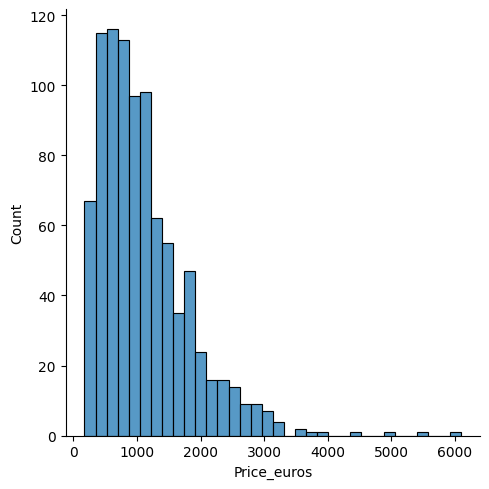

In [6]:
sns.displot(df_portatiles_train["Price_euros"])

<Axes: ylabel='Price_euros'>

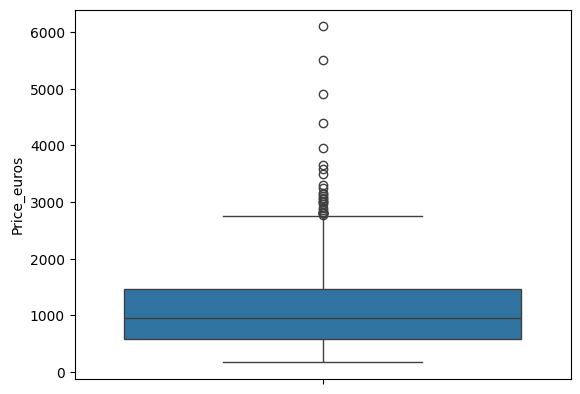

In [7]:
sns.boxplot(df_portatiles_train["Price_euros"])

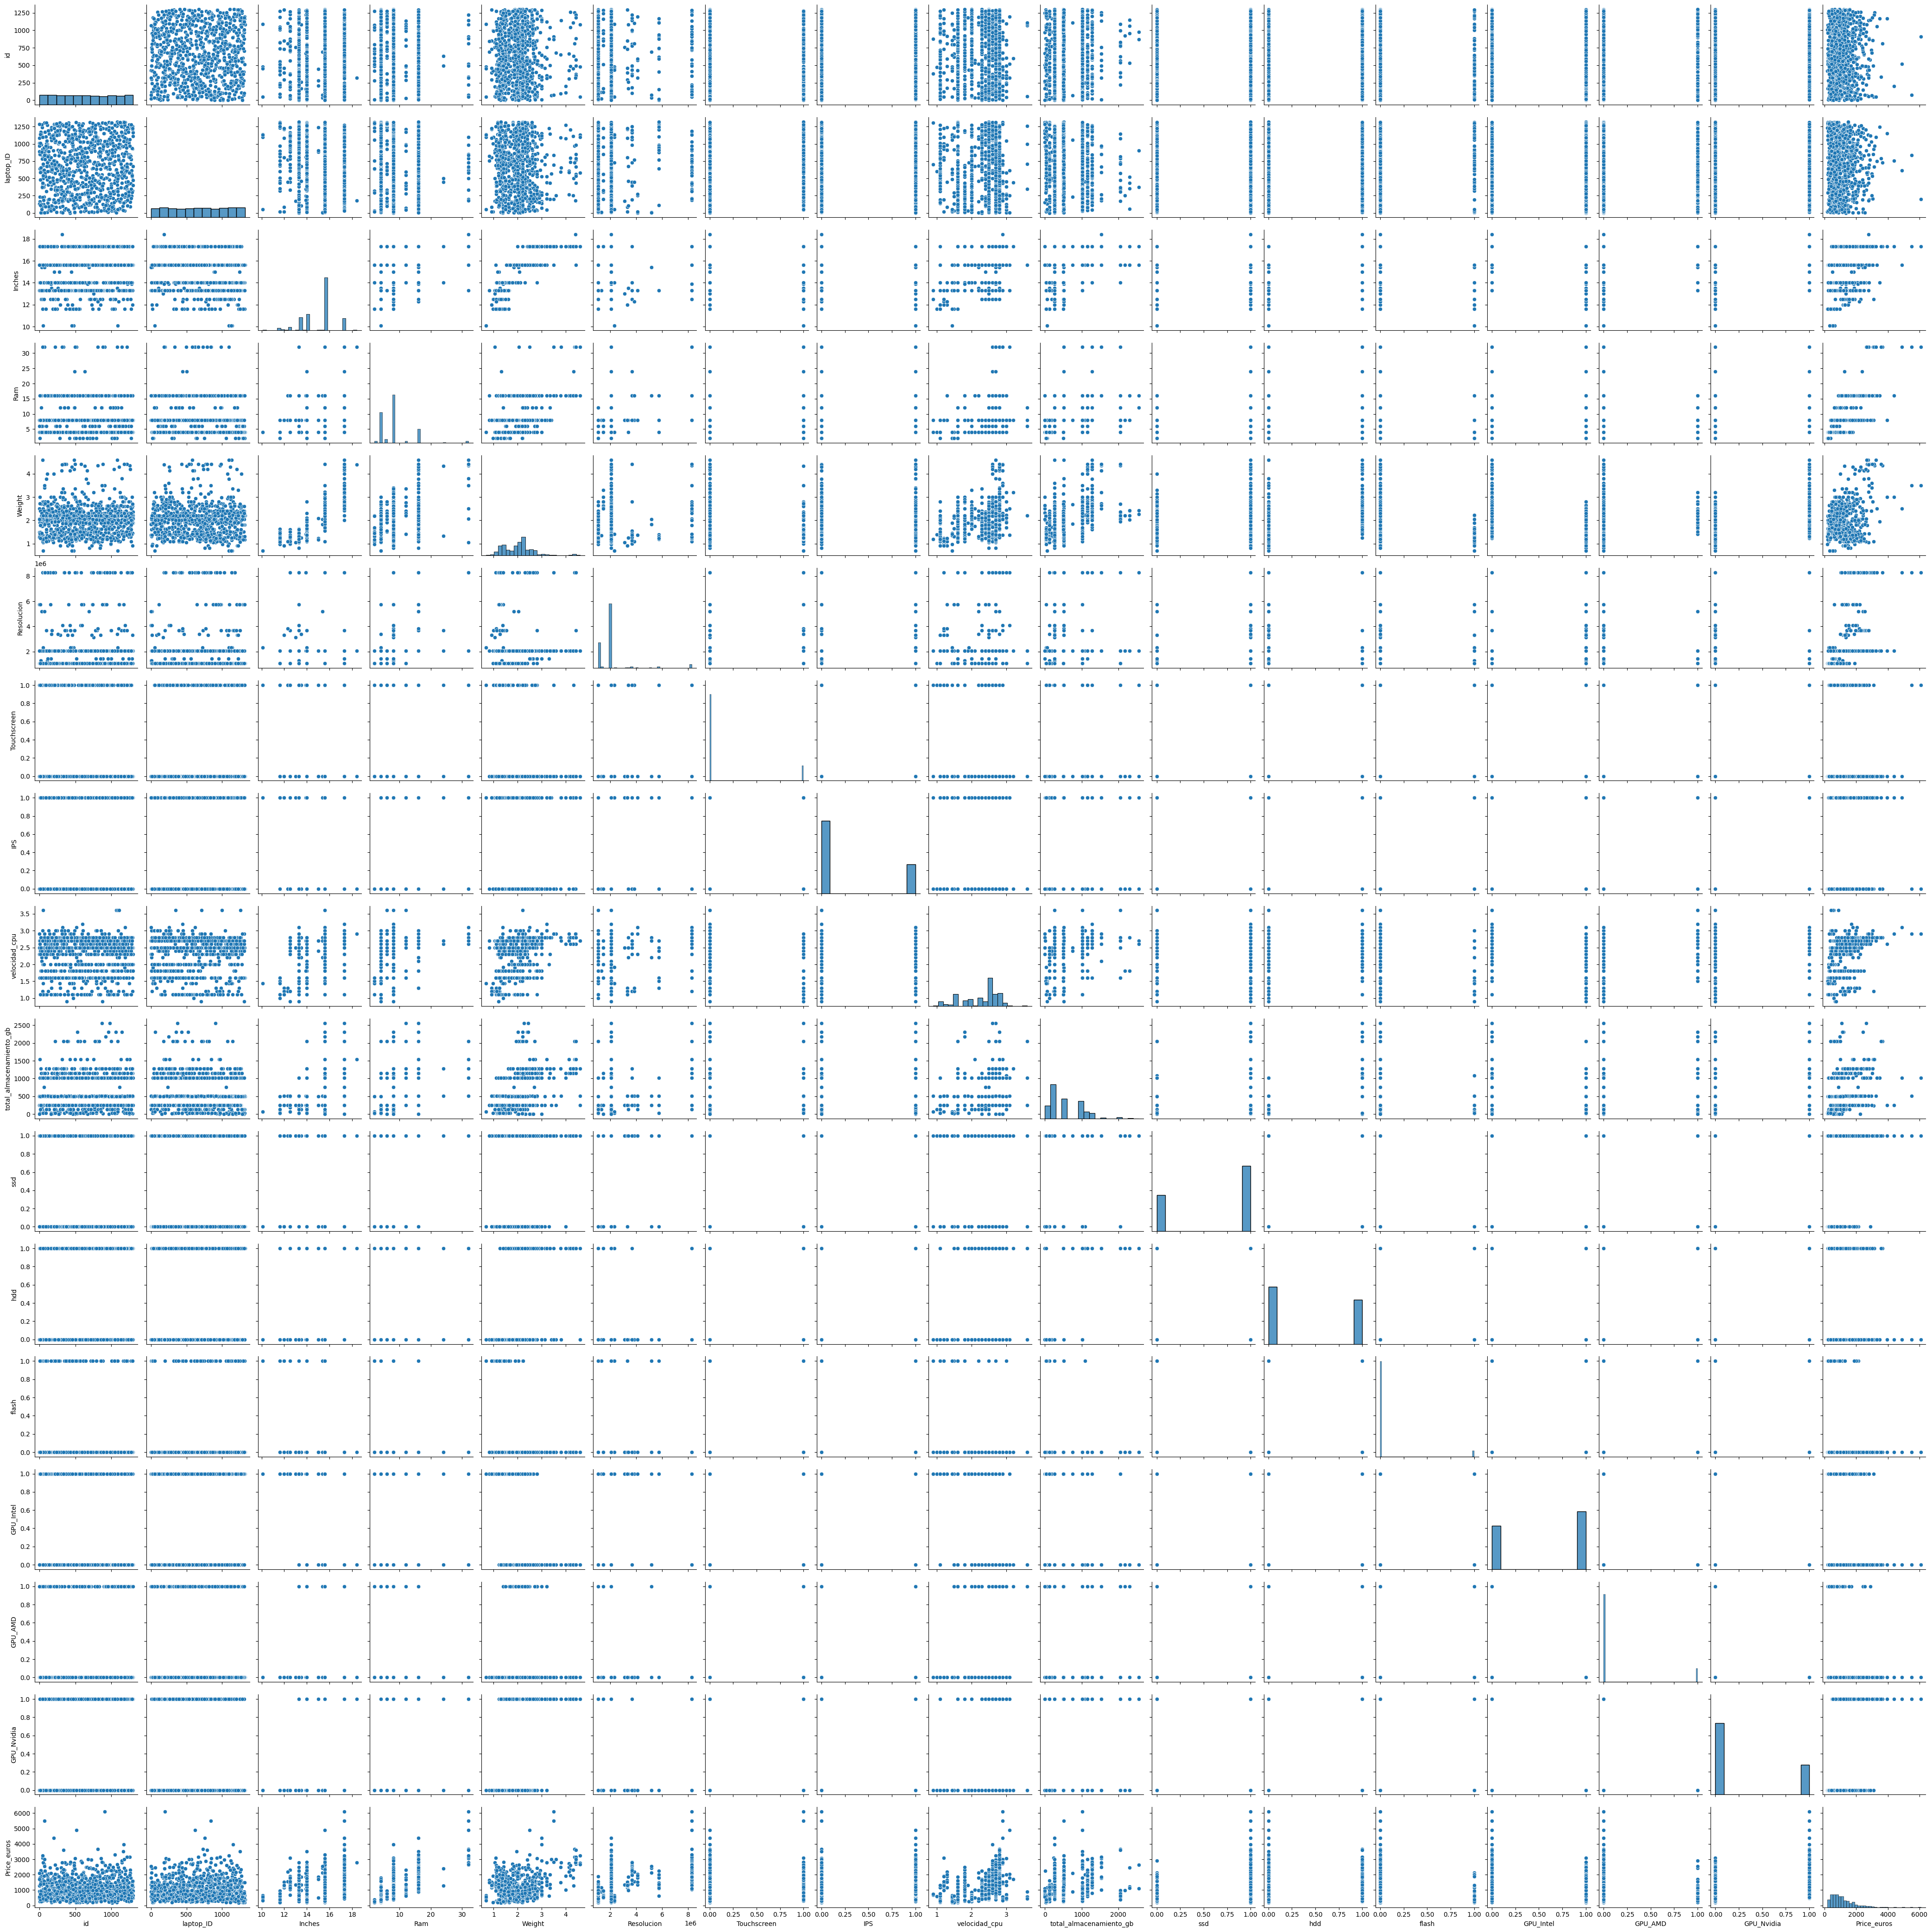

In [8]:
sns.pairplot(df_portatiles_train)

In [9]:
df_portatiles_train.corr(numeric_only=True)

,id,laptop_ID,Inches,Ram,Weight,Resolucion,Touchscreen,IPS,velocidad_cpu,total_almacenamiento_gb,ssd,hdd,flash,GPU_Intel,GPU_AMD,GPU_Nvidia,Price_euros
id,1.000000,0.008007,0.028012,-0.016759,0.032515,-0.001695,-0.032643,-0.003624,0.004369,0.048967,0.012381,0.021130,-0.033892,-0.028650,0.036735,0.003664,-0.012740
laptop_ID,0.008007,1.000000,-0.100320,-0.063485,-0.021699,-0.045960,0.040879,-0.029944,0.080922,-0.034761,-0.112535,0.054531,0.050370,0.079865,-0.078459,-0.028107,0.052808
Inches,0.028012,-0.100320,1.000000,0.245243,0.830464,-0.051240,-0.370802,-0.099530,0.294392,0.495854,-0.066194,0.499956,-0.355984,-0.570118,0.192469,0.475359,0.077798
Ram,-0.016759,-0.063485,0.245243,1.000000,0.416750,0.448450,0.125682,0.210111,0.378765,0.364655,0.383968,0.014782,-0.186115,-0.351400,-0.090118,0.448988,0.747748
Weight,0.032515,-0.021699,0.830464,0.416750,1.000000,0.007519,-0.275896,0.015827,0.317567,0.520492,-0.009999,0.492448,-0.263597,-0.586449,0.102697,0.560181,0.231864
Resolucion,-0.001695,-0.045960,-0.051240,0.448450,0.007519,1.000000,0.336003,0.263789,0.163733,0.062795,0.319208,-0.193803,-0.072918,-0.118934,-0.093118,0.198755,0.550249
Touchscreen,-0.032643,0.040879,-0.370802,0.125682,-0.275896,0.336003,1.000000,0.150725,-0.084027,-0.119584,0.134201,-0.234901,0.027108,0.239780,-0.144894,-0.152142,0.176573
IPS,-0.003624,-0.029944,-0.099530,0.210111,0.015827,0.263789,0.150725,1.000000,0.076576,-0.000467,0.235062,-0.133877,0.006846,-0.065091,-0.111770,0.154217,0.270170
velocidad_cpu,0.004369,0.080922,0.294392,0.378765,0.317567,0.163733,-0.084027,0.076576,1.000000,0.243958,0.277802,0.098883,-0.389836,-0.379849,0.040668,0.382152,0.439406
total_almacenamiento_gb,0.048967,-0.034761,0.495854,0.364655,0.520492,0.062795,-0.119584,-0.000467,0.243958,1.000000,-0.198830,0.781427,-0.259248,-0.436061,0.112256,0.389706,0.170139


<Axes: >

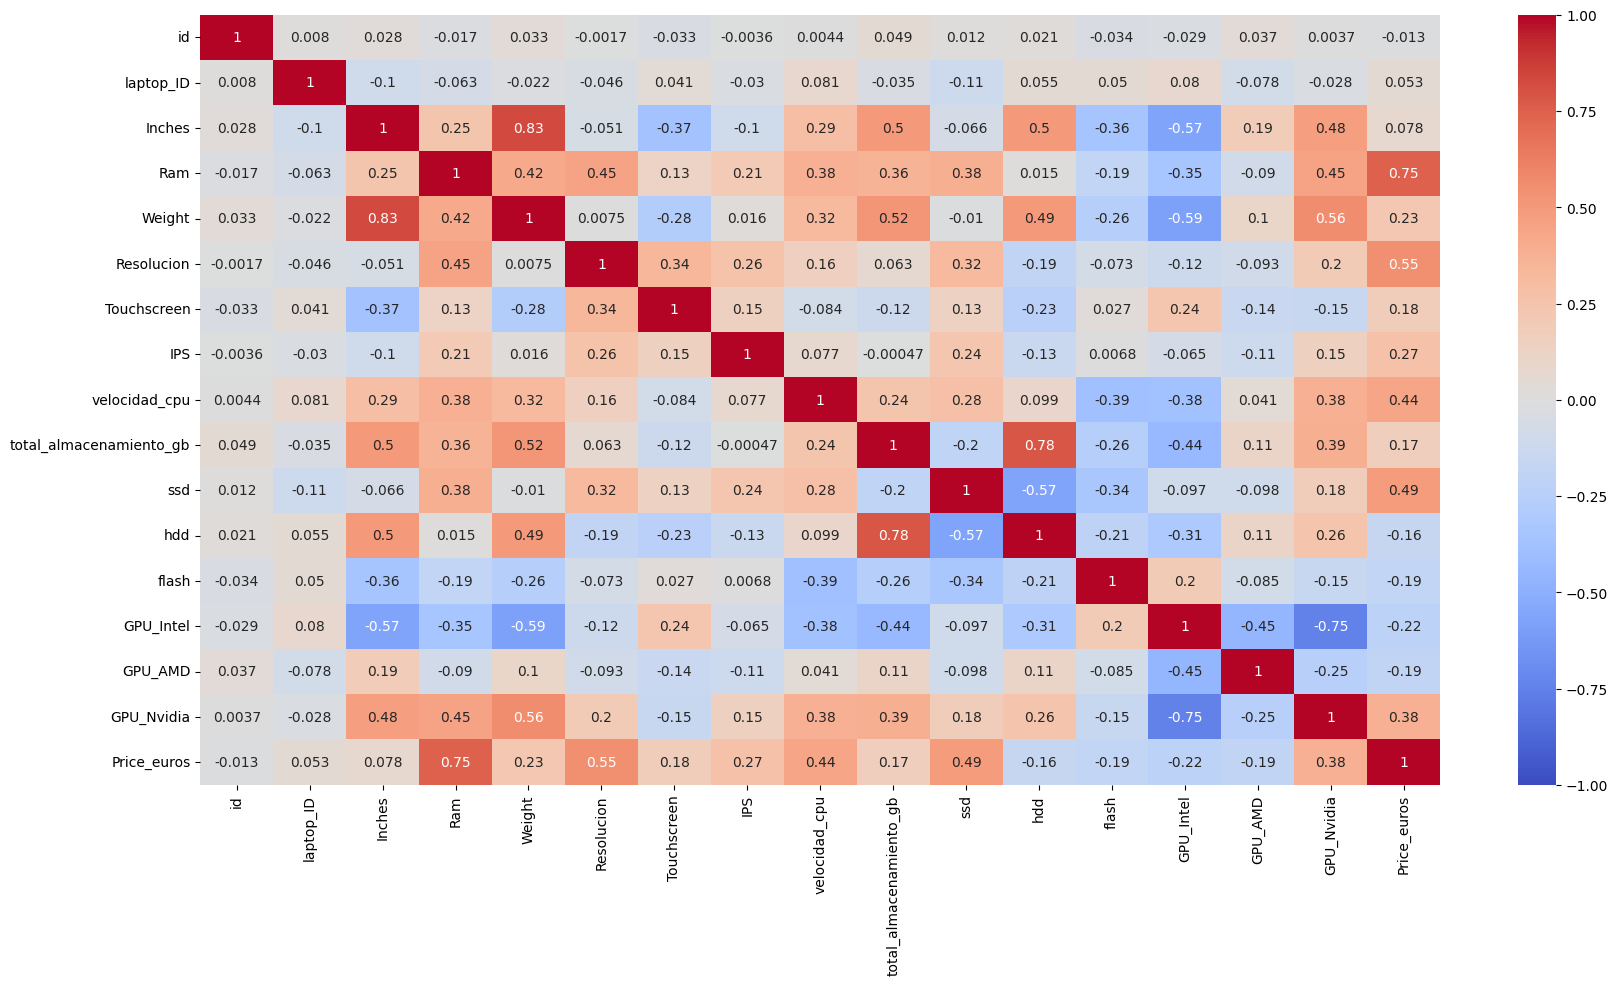

In [10]:
plt.figure(figsize=(20, 10))
sns.heatmap(df_portatiles_train.corr(numeric_only=True), annot=True, vmin=-1, cmap="coolwarm")

### Regresión lineal

In [98]:
# Columnas que queremos usar
columnas_numericas = ["Inches", "Ram", "Weight", "Resolucion", "Touchscreen",
                      "IPS", "velocidad_cpu", "total_almacenamiento_gb",
                      "ssd", "hdd", "flash", "GPU_Intel", "GPU_AMD", "GPU_Nvidia"]
columnas_categoricas = ["TypeName", "marca_cpu", "OpSys"]

# Seleccionar solo las columnas que nos interesan
df = df_portatiles_train[columnas_numericas + columnas_categoricas + ["Price_euros"]]

# One-hot encode solo las categóricas
df_encoded = pd.get_dummies(df, columns=columnas_categoricas, drop_first=False)

# Separar X e y
X = df_encoded.drop("Price_euros", axis=1)
y = df_encoded["Price_euros"]

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=11)

# Escalar solo las columnas numéricas
scaler = StandardScaler()
scaler.fit(X_train[columnas_numericas])

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[columnas_numericas] = scaler.transform(X_train[columnas_numericas])
X_test_scaled[columnas_numericas] = scaler.transform(X_test[columnas_numericas])

# Entrenar modelo
linear_model = LinearRegression()
linear_model.fit(X_train_scaled, y_train)

# Predecir
pred = linear_model.predict(X_test_scaled)

# Métricas
print("MAE: ", metrics.mean_absolute_error(y_test, pred))
print("RMSE: ", np.sqrt(metrics.mean_squared_error(y_test, pred)))
print("MAPE: ", metrics.mean_absolute_percentage_error(y_test, pred))
print("R2: ", metrics.r2_score(y_test, pred))

MAE:  275.85024421777996
RMSE:  410.92863615391826
MAPE:  0.26657506763423344
R2:  0.6841885925072817


In [76]:
columnas_numericas = [
    "Inches",           
    "Ram",               
    "Weight",           
    "Resolucion",        
    "Touchscreen",       
    "IPS",               
    "velocidad_cpu",     
    "total_almacenamiento_gb", 
    "ssd", "hdd", "flash",      
    "GPU_Intel", "GPU_AMD", "GPU_Nvidia"  
]

columnas_categoricas = [    
    "TypeName",
    "marca_cpu",
    "OpSys"
]

In [77]:
df_encoded = pd.get_dummies(df_train, columns=columnas_categoricas, drop_first=False)
df_encoded

,id,laptop_ID,Company,Product,Inches,Ram,Weight,Resolucion,Touchscreen,IPS,...,marca_cpu_Intel,OpSys_Android,OpSys_Chrome OS,OpSys_Linux,OpSys_Mac OS X,OpSys_No OS,OpSys_Windows 10,OpSys_Windows 10 S,OpSys_Windows 7,OpSys_macOS
0,268,1002,Dell,Inspiron 5567,15.6,8.0,2.36,1049088,0,0,...,True,False,False,False,False,False,True,False,False,False
1,347,867,Asus,X541NA (N4200/4GB/1TB/W10),15.6,4.0,2.00,1049088,0,0,...,True,False,False,False,False,False,True,False,False,False
2,353,966,Toshiba,Portege Z30-C-1CW,13.3,8.0,1.20,2073600,0,0,...,True,False,False,False,False,False,False,False,True,False
3,578,767,Dell,Alienware 17,15.6,16.0,4.42,8294400,0,1,...,True,False,False,False,False,False,True,False,False,False
4,42,1241,Dell,Latitude E7270,12.5,8.0,1.26,2073600,1,0,...,True,False,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
907,89,973,Acer,Chromebook C738T-C2EJ,11.6,4.0,1.25,1049088,1,1,...,True,False,True,False,False,False,False,False,False,False
908,716,1018,Toshiba,Portege Z30-C-16H,13.3,4.0,1.20,2073600,0,0,...,True,False,False,False,False,False,True,False,False,False
909,517,1071,Acer,Aspire ES1-523,15.6,8.0,2.40,1049088,0,0,...,False,False,False,False,False,False,True,False,False,False
910,891,965,Dell,Latitude 7480,14.0,8.0,1.36,2073600,0,0,...,True,False,False,False,False,False,True,False,False,False


In [78]:
X = df_encoded
y = df_portatiles_train["Price_euros"]

In [79]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=11)

print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(729, 36)
(729,)
(183, 36)
(183,)


In [82]:
scaler = StandardScaler()
scaler.fit(X_train[columnas_numericas])

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[columnas_numericas] = scaler.transform(X_train[columnas_numericas])
X_test_scaled[columnas_numericas] = scaler.transform(X_test[columnas_numericas])

In [83]:
linear_model = LinearRegression()
linear_model.fit(X_train_scaled, y_train)

ValueError: could not convert string to float: 'Lenovo'

In [ ]:
pred = linear_model.predict(X_test_st)

print("MAE: ", metrics.mean_absolute_error(y_test, pred))
print("RMSE: ", metrics.root_mean_squared_error(y_test, pred))
print("MAPE: ", metrics.mean_absolute_percentage_error(y_test, pred))
print("R2: ", metrics.r2_score(y_test, pred))

MAE:  275.85024421778013
RMSE:  410.92863615391826
MAPE:  0.2665750676342337
R2:  0.6841885925072817


### Modelo de regresión polinómica

In [18]:
poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

model_poly = LinearRegression()
model_poly.fit(X_train_poly, y_train)

pred_poly = model_poly.predict(X_test_poly)

print("______________MÉTRICAS______________")
print("MAE: ", metrics.mean_absolute_error(y_test, pred_poly))
print("RMSE: ", metrics.root_mean_squared_error(y_test, pred_poly))
print("MAPE: ", metrics.mean_absolute_percentage_error(y_test, pred_poly))
print("R2: ", metrics.r2_score(y_test, pred_poly))

______________MÉTRICAS______________
MAE:  277.8881463292388
RMSE:  410.6564837013032
MAPE:  0.26980322469271995
R2:  0.6846067691938209


In [19]:
st = StandardScaler()
st.fit(X_train)

X_train_st = st.transform(X_train)
X_test_st = st.transform(X_test)

In [20]:
poly_02 = PolynomialFeatures(degree=2)
X_train_poly = poly_02.fit_transform(X_train_st)
X_test_poly = poly_02.transform(X_test_st)

model_poly_02 = LinearRegression()
model_poly_02.fit(X_train_poly, y_train)

pred_poly_02 = model_poly_02.predict(X_test_poly)

print("______________MÉTRICAS______________")
print("MAE: ", metrics.mean_absolute_error(y_test, pred_poly_02))
print("RMSE: ", metrics.root_mean_squared_error(y_test, pred_poly_02))
print("MAPE: ", metrics.mean_absolute_percentage_error(y_test, pred_poly_02))
print("R2: ", metrics.r2_score(y_test, pred_poly_02))

______________MÉTRICAS______________
MAE:  277.13686346121716
RMSE:  411.16583434001865
MAPE:  0.26326281311437605
R2:  0.683823898950604


### Ridge

In [21]:
ridge = Ridge(alpha=25)
ridge.fit(X_train_st, y_train)

pred_r = ridge.predict(X_test_st)

print("______________MÉTRICAS______________")
print("MAE: ", metrics.mean_absolute_error(y_test, pred_r))
print("RMSE: ", metrics.root_mean_squared_error(y_test, pred_r))
print("MAPE: ", metrics.mean_absolute_percentage_error(y_test, pred_r))
print("R2: ", metrics.r2_score(y_test, pred_r))

______________MÉTRICAS______________
MAE:  274.49774059493643
RMSE:  412.28678011310205
MAPE:  0.266835176702772
R2:  0.6820975912169854


### Lasso

In [22]:
lasso = Lasso(alpha=9)
lasso.fit(X_train_st, y_train)

pred_l = lasso.predict(X_test_st)

print("______________MÉTRICAS______________")
print("MAE: ", metrics.mean_absolute_error(y_test, pred_l))
print("RMSE: ", metrics.root_mean_squared_error(y_test, pred_l))
print("MAPE: ", metrics.mean_absolute_percentage_error(y_test, pred_l))
print("R2: ", metrics.r2_score(y_test, pred_l))

______________MÉTRICAS______________
MAE:  273.3212811461055
RMSE:  413.11074162453525
MAPE:  0.26165206487306675
R2:  0.6808256557254858


In [23]:
df_original = pd.read_csv("data/train.csv", sep=",")
df_original.head()

,id,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_euros
0,268,1002,Dell,Inspiron 5567,Notebook,15.6,1366x768,Intel Core i7 7500U 2.7GHz,8GB,1TB HDD,AMD Radeon R7 M445,Windows 10,2.36kg,749.00
1,347,867,Asus,X541NA (N4200/4GB/1TB/W10),Notebook,15.6,1366x768,Intel Pentium Quad Core N4200 1.1GHz,4GB,1TB HDD,Intel HD Graphics 505,Windows 10,2kg,449.00
2,353,966,Toshiba,Portege Z30-C-1CW,Notebook,13.3,Full HD 1920x1080,Intel Core i5 6200U 2.3GHz,8GB,256GB SSD,Intel HD Graphics 520,Windows 7,1.2kg,1460.00
3,578,767,Dell,Alienware 17,Gaming,15.6,IPS Panel 4K Ultra HD 3840x2160,Intel Core i7 7700HQ 2.8GHz,16GB,256GB SSD + 1TB HDD,Nvidia GeForce GTX 1070,Windows 10,4.42kg,2868.99
4,42,1241,Dell,Latitude E7270,Ultrabook,12.5,Full HD / Touchscreen 1920x1080,Intel Core i5 6300U 2.4GHz,8GB,256GB SSD,Intel HD Graphics 520,Windows 7,1.26kg,1713.37


### Elastic net

In [24]:
elastic_net = ElasticNet(alpha = 0.0001, l1_ratio = 0.7)
elastic_net.fit(X_train_st, y_train)

pred_en = elastic_net.predict(X_test_st)

print("______________MÉTRICAS______________")
print("MAE: ", metrics.mean_absolute_error(y_test, pred_en))
print("RMSE: ", metrics.root_mean_squared_error(y_test, pred_en))
print("MAPE: ", metrics.mean_absolute_percentage_error(y_test, pred_en))
print("R2: ", metrics.r2_score(y_test, pred_en))

______________MÉTRICAS______________
MAE:  274.92266123880876
RMSE:  412.3427128007859
MAPE:  0.26615106455540427
R2:  0.6820113292113292


c:\Users\Administrador\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.535e+07, tolerance: 3.672e+04
  model = cd_fast.enet_coordinate_descent(


# TABLA DE PREDICCIONES

In [ ]:
# Preprocesamiento test.csv de Kaggle
df_test = pd.read_csv("data/test_kaggle_procesado.csv")  # el que te dan en Kaggle
df_test_proc = df_test[["TypeName","marca_cpu","OpSys","Ram","ScreenWidth",
                        "velocidad_cpu","ssd","hdd","total_almacenamiento_gb",
                        "GPU_Nvidia","IPS","Touchscreen","Weight"]]

df_test_encoded = pd.get_dummies(df_test_proc, columns=["TypeName","marca_cpu","OpSys"], drop_first=False)

# Asegurar que el test tenga las mismas columnas que el train
df_test_encoded = df_test_encoded.reindex(columns=X_train.columns, fill_value=0)

X_test_st = st.transform(df_test_encoded)

# Predecir
predictions = lasso.predict(X_test_st)

predictions


array([2220.28477753,  546.68740276,  404.35998885, 1018.63350954,
        865.41101586, 1540.15378638, 1707.99986761,  613.53893762,
       5018.07803047, 1284.832518  , 1235.10217164,  307.29666951,
        254.63573156,  485.58009602,  597.41555835,  908.72995549,
        630.51490771, 1268.04790987, 1126.92986109, 1181.16642996,
       1315.87448029,  899.4599089 , 1446.48102239, 1050.47148229,
       1707.99986761,  540.19772305,  708.09393146,  100.62627375,
       1019.96660106,  223.3736289 , 1134.44442263,  831.84179961,
       1674.43065137,  680.5625715 ,  281.49110456, 1707.99986761,
        693.98301732,  485.71229188, 2830.53180823,  376.16762755,
        273.72745327,  727.55223357, 1167.96373915, 1694.7971768 ,
       1050.47148229, 1289.36465893,  647.76938272, 2826.94989092,
        321.09817708, 1524.50210384,  898.98023211,  590.6016746 ,
        845.04449043,  337.22155636, 1106.56333565,  301.85763   ,
        569.50313663,   18.46451951,  861.82909855, 1106.56333

In [31]:
df_test

,id,Company,TypeName,Inches,Ram,OpSys,Weight,ScreenWidth,ScreenHeight,Touchscreen,IPS,marca_cpu,velocidad_cpu,total_almacenamiento_gb,ssd,hdd,flash,GPU_Intel,GPU_AMD,GPU_Nvidia
0,181,6,4,13.3,16.0,4,1.30,3840,2160,0,1,1,2.7,512.0,1,0,0,1,0,0
1,708,0,3,15.6,8.0,4,2.20,1366,768,0,0,0,2.7,256.0,1,0,0,0,1,0
2,862,0,3,15.6,4.0,1,2.40,1366,768,0,0,1,2.0,500.0,0,1,0,1,0,0
3,1064,6,3,14.0,8.0,6,1.43,1920,1080,0,0,1,2.3,256.0,1,0,0,1,0,0
4,702,6,3,13.3,8.0,4,1.34,1920,1080,0,1,1,2.5,256.0,1,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
386,1281,9,1,15.6,8.0,3,2.40,1920,1080,0,1,1,2.8,256.0,1,0,0,0,0,1
387,524,9,1,15.6,16.0,4,3.31,1920,1080,0,1,1,2.6,512.0,1,0,0,0,0,1
388,1015,6,3,15.6,4.0,3,1.96,1366,768,0,0,1,2.5,500.0,0,1,0,1,0,0
389,1236,6,3,15.6,4.0,4,2.10,1920,1080,0,0,0,1.5,500.0,0,1,0,0,1,0


In [29]:
# Crear submission.csv
submission = pd.DataFrame({"id": df_test["id"], "Price_euros": predictions})
submission.to_csv("data/sample_submission.csv", index=False)

In [30]:
submission

,id,Price_euros
0,181,2220.284778
1,708,546.687403
2,862,404.359989
3,1064,1018.633510
4,702,865.411016
...,...,...
386,1281,1426.069707
387,524,1694.797177
388,1015,556.082691
389,1236,58.036101
